# V3 프로모션 그룹 분리 분석

**분석 순서**
1. 전체 데이터로 기준 모델 학습 → SHAP 중요도 확보
2. VIF + SHAP 결합 반복 제거 → 정제 변수셋 확정
3. 정제 변수셋 기준으로 프로모션 그룹 분리
4. 그룹 A (is_promotion=0) 독립 분석
5. 그룹 B (is_promotion=1) 독립 분석
6. 두 그룹 비교

> 변수 선택은 전체 데이터 기준으로 하고, 동일한 변수셋으로 각 그룹을 비교합니다.

In [6]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

from pathlib import Path
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
import xgboost as xgb
import shap

BASE = Path('../..').resolve()
SEED = 42

df = pd.read_csv(
    BASE / '_data/02_interim/260513 feature/Membership_v3.csv',
    encoding='utf-8-sig'
)
print(f'V3 shape: {df.shape}')

V3 shape: (23343, 91)


In [7]:
EXCLUDE = [
    'USER_KEY', 'product_code', 'payment_device',
    'gender', 'reg_date', 'end_date', 'is_repurchase',
    'billing_method','price','max_screen','age',
    'reg_hour'
]
EXCLUDE = [c for c in EXCLUDE if c in df.columns]

df_enc = df.copy()
for col in df_enc.select_dtypes('object').columns:
    if col not in EXCLUDE:
        df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))

FEAT_ALL = [c for c in df_enc.columns if c not in EXCLUDE]
X_all    = df_enc[FEAT_ALL].fillna(0)
y_all    = df_enc['is_repurchase']

print(f'전체 변수 수: {len(FEAT_ALL)}개')
print(f'이탈(0): {(y_all==0).sum():,}명 / 재구매(1): {(y_all==1).sum():,}명')
print(f'프로모션=0: {(df_enc["is_promotion"]==0).sum():,}명')
print(f'프로모션=1: {(df_enc["is_promotion"]==1).sum():,}명')

전체 변수 수: 79개
이탈(0): 6,641명 / 재구매(1): 16,702명
프로모션=0: 11,388명
프로모션=1: 11,955명


In [8]:
def calc_vif(X_df):
    Xv = X_df.select_dtypes(include=[np.number]).copy()
    Xv = Xv.drop(columns=[c for c in Xv.columns if Xv[c].var() == 0])
    Xv.insert(0, 'const', 1)
    vals = Xv.values.astype(float)
    result = []
    for i in range(1, len(Xv.columns)):
        try:
            v = variance_inflation_factor(vals, i)
        except Exception:
            v = np.inf
        result.append({'변수': Xv.columns[i], 'VIF': v})
    return pd.DataFrame(result)

print('calc_vif 함수 정의 완료')

calc_vif 함수 정의 완료


## 1. 전체 데이터 기준 모델 & VIF+SHAP 정제

전체 데이터로 모델을 학습해 SHAP 중요도를 확보한 뒤, VIF+SHAP 반복 제거로 변수셋을 확정합니다.
이 변수셋을 두 그룹이 공통으로 사용합니다.

In [9]:
X_tr_all, X_te_all, y_tr_all, y_te_all = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=SEED
)
spw = (y_tr_all==0).sum() / (y_tr_all==1).sum()

model_full = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    scale_pos_weight=spw, subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', early_stopping_rounds=50,
    random_state=SEED, n_jobs=-1, verbosity=0
)
model_full.fit(X_tr_all, y_tr_all, eval_set=[(X_te_all, y_te_all)], verbose=False)

yp_all  = model_full.predict(X_te_all)
ypr_all = model_full.predict_proba(X_te_all)[:,1]
print(f'[전체 기준 모델] AUC={roc_auc_score(y_te_all, ypr_all):.4f}  F1={f1_score(y_te_all, yp_all):.4f}  변수={len(FEAT_ALL)}개')

exp_full   = shap.TreeExplainer(model_full)
shap_full  = exp_full.shap_values(X_te_all)
shap_imp   = pd.DataFrame({'변수': FEAT_ALL, 'SHAP': np.abs(shap_full).mean(axis=0)}).sort_values('SHAP', ascending=False).reset_index(drop=True)
shap_imp.index += 1
print('\n=== 전체 SHAP 중요도 (상위 20) ===')
print(shap_imp.head(20).to_string())

[전체 기준 모델] AUC=0.8839  F1=0.8541  변수=79개

=== 전체 SHAP 중요도 (상위 20) ===
                        변수      SHAP
1       retention_w2_ratio  0.437786
2       watch_time(min)_w3  0.435806
3             is_promotion  0.354904
4              drama_ratio  0.354083
5   family_animation_ratio  0.323208
6       retention_w3_ratio  0.310597
7         is_cold_start_3d  0.296924
8            romance_ratio  0.294970
9     thriller_crime_ratio  0.278087
10  action_adventure_ratio  0.243976
11      diff_between_w3_w2  0.237291
12      diff_between_w2_w1  0.222952
13  median_watch_time(min)  0.155033
14      is_churn_prevented  0.121530
15           max_day_share  0.116125
16     std_watch_time(min)  0.106667
17             is_standard  0.105732
18     max_watch_time(min)  0.103570
19   genre_diversity_count  0.090982
20              is_premium  0.090818


In [10]:
VIF_THRESHOLD = 10
shap_dict     = dict(zip(shap_imp['변수'], shap_imp['SHAP']))

FEAT_REF    = FEAT_ALL.copy()
removed_log = []
print(f'시작: {len(FEAT_REF)}개 변수 | VIF 임계값: {VIF_THRESHOLD}\n')

while True:
    vif_df   = calc_vif(X_all[FEAT_REF])
    high_vif = vif_df[np.isinf(vif_df['VIF']) | (vif_df['VIF'] > VIF_THRESHOLD)].copy()
    if len(high_vif) == 0:
        print(f'\n완료! 모든 변수 VIF <= {VIF_THRESHOLD}  (최종: {len(FEAT_REF)}개)')
        break
    high_vif['SHAP'] = high_vif['변수'].map(shap_dict).fillna(0)
    target  = high_vif.sort_values('SHAP').iloc[0]
    vif_str = 'inf' if np.isinf(target['VIF']) else f"{target['VIF']:.1f}"
    FEAT_REF.remove(target['변수'])
    step = len(removed_log) + 1
    removed_log.append({'step': step, '제거변수': target['변수'],
                        'VIF': vif_str, 'SHAP': round(target['SHAP'], 4), '잔여': len(FEAT_REF)})
    print(f"[{step:2d}] 제거: {target['변수']:<38}  VIF={vif_str:>8}  SHAP={target['SHAP']:.4f}  남은: {len(FEAT_REF)}개")

X_ref = X_all[FEAT_REF]
print(f'\n전체: {len(FEAT_ALL)}개 -> 정제: {len(FEAT_REF)}개  ({len(FEAT_ALL)-len(FEAT_REF)}개 제거)')
print('\n=== 제거 로그 ===')
print(pd.DataFrame(removed_log).to_string(index=False))

print('\n=== 최종 VIF 검증 ===')
fvif = calc_vif(X_ref).sort_values('VIF', ascending=False).reset_index(drop=True)
fvif['위험도'] = fvif['VIF'].apply(lambda v: '주의(5~10)' if v > 5 else '양호')
print(fvif.to_string())
print(f'\nVIF 최대값: {fvif["VIF"].max():.2f}  /  평균: {fvif["VIF"].mean():.2f}')

시작: 79개 변수 | VIF 임계값: 10

[ 1] 제거: active_ratio                            VIF=1488055386542.4  SHAP=0.0045  남은: 78개
[ 2] 제거: reg_hour_afternoon                      VIF=     inf  SHAP=0.0048  남은: 77개
[ 3] 제거: documentary_ratio                       VIF= 43296.3  SHAP=0.0116  남은: 76개
[ 4] 제거: total_watch_count                       VIF=     inf  SHAP=0.0125  남은: 75개
[ 5] 제거: payment_is_android                      VIF=    16.2  SHAP=0.0155  남은: 74개
[ 6] 제거: watch_session_w2                        VIF=    10.4  SHAP=0.0211  남은: 73개
[ 7] 제거: watch_days                              VIF=    13.3  SHAP=0.0232  남은: 72개
[ 8] 제거: new_movie_in_180d_ratio                 VIF=    12.8  SHAP=0.0268  남은: 71개
[ 9] 제거: max_inactive_gap_days                   VIF=    11.4  SHAP=0.0274  남은: 70개
[10] 제거: watch_per_day                           VIF=    13.3  SHAP=0.0325  남은: 69개
[11] 제거: watch_time(min)_w2                      VIF=     inf  SHAP=0.0352  남은: 68개
[12] 제거: max_daily_watch_time(min)         

## 2. 정제 변수셋으로 프로모션 그룹 분리

In [11]:
mask0 = (df_enc['is_promotion'] == 0).values
mask1 = (df_enc['is_promotion'] == 1).values

XA, yA = X_ref[mask0].reset_index(drop=True), y_all[mask0].reset_index(drop=True)
XB, yB = X_ref[mask1].reset_index(drop=True), y_all[mask1].reset_index(drop=True)

print(f'정제 변수셋: {len(FEAT_REF)}개')
print(f'그룹 A (is_promotion=0): {len(XA):,}명  이탈: {(yA==0).sum():,} / 재구매: {(yA==1).sum():,}')
print(f'그룹 B (is_promotion=1): {len(XB):,}명  이탈: {(yB==0).sum():,} / 재구매: {(yB==1).sum():,}')

정제 변수셋: 61개
그룹 A (is_promotion=0): 11,388명  이탈: 2,746 / 재구매: 8,642
그룹 B (is_promotion=1): 11,955명  이탈: 3,895 / 재구매: 8,060


---
## 3. 그룹 A: is_promotion = 0 (일반 가입)

### A-1. 모델 학습 & SHAP

[그룹 A] AUC=0.8749  F1=0.8644
Precision: 0.9025  Recall: 0.8294


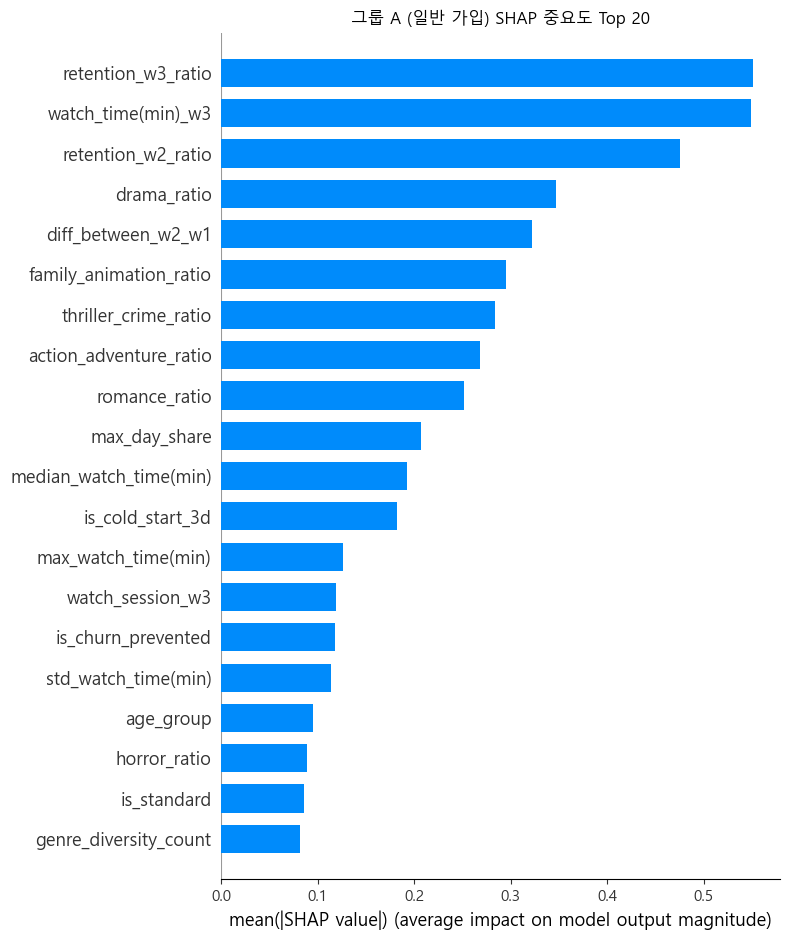

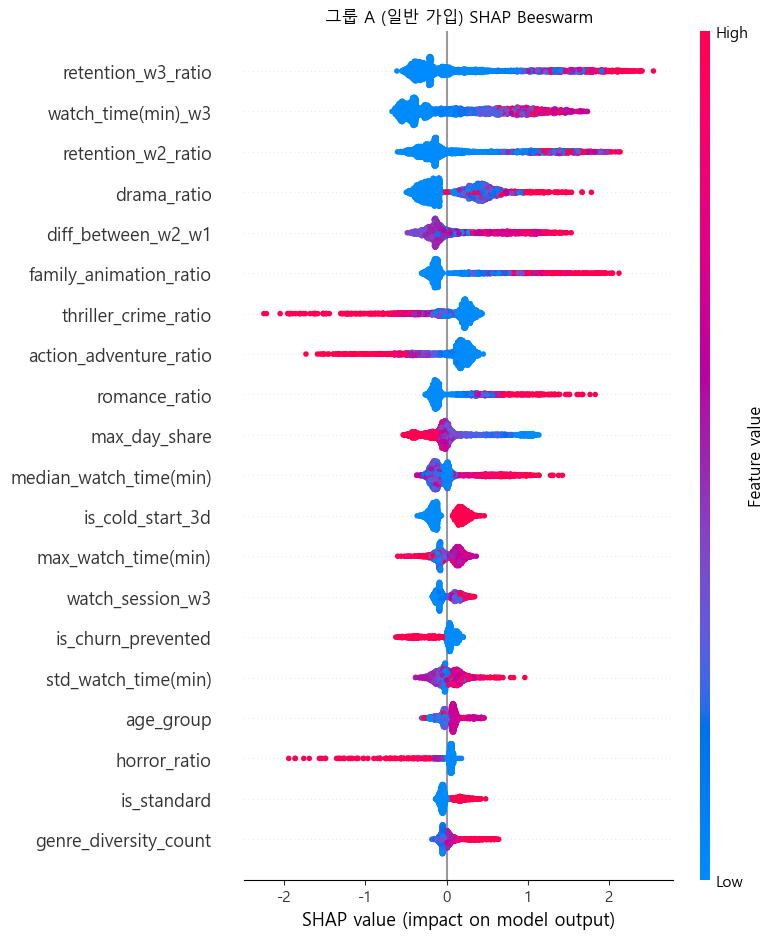

=== 그룹 A SHAP 중요도 (상위 20) ===
                        변수      SHAP
1       retention_w3_ratio  0.551742
2       watch_time(min)_w3  0.549469
3       retention_w2_ratio  0.475215
4              drama_ratio  0.346518
5       diff_between_w2_w1  0.322541
6   family_animation_ratio  0.295177
7     thriller_crime_ratio  0.283391
8   action_adventure_ratio  0.268638
9            romance_ratio  0.251983
10           max_day_share  0.206930
11  median_watch_time(min)  0.192196
12        is_cold_start_3d  0.181831
13     max_watch_time(min)  0.125870
14        watch_session_w3  0.118685
15      is_churn_prevented  0.117967
16     std_watch_time(min)  0.114047
17               age_group  0.094876
18            horror_ratio  0.088551
19             is_standard  0.085238
20   genre_diversity_count  0.081761


In [12]:
X_trA, X_teA, y_trA, y_teA = train_test_split(
    XA, yA, test_size=0.2, stratify=yA, random_state=SEED
)
spwA = (y_trA==0).sum() / (y_trA==1).sum()
model_A = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    scale_pos_weight=spwA, subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', early_stopping_rounds=50,
    random_state=SEED, n_jobs=-1, verbosity=0
)
model_A.fit(X_trA, y_trA, eval_set=[(X_teA, y_teA)], verbose=False)

ypA  = model_A.predict(X_teA)
yprA = model_A.predict_proba(X_teA)[:,1]
print(f'[그룹 A] AUC={roc_auc_score(y_teA, yprA):.4f}  F1={f1_score(y_teA, ypA):.4f}')
print(f'Precision: {precision_score(y_teA, ypA):.4f}  Recall: {recall_score(y_teA, ypA):.4f}')

exp_A   = shap.TreeExplainer(model_A)
shap_A  = exp_A.shap_values(X_teA)
shap_dfA = pd.DataFrame({'변수': FEAT_REF, 'SHAP': np.abs(shap_A).mean(axis=0)}).sort_values('SHAP', ascending=False).reset_index(drop=True)
shap_dfA.index += 1

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_A, X_teA, plot_type='bar', show=False, max_display=20)
plt.title('그룹 A (일반 가입) SHAP 중요도 Top 20')
plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_A, X_teA, show=False, max_display=20)
plt.title('그룹 A (일반 가입) SHAP Beeswarm')
plt.tight_layout(); plt.show()

print('=== 그룹 A SHAP 중요도 (상위 20) ===')
print(shap_dfA.head(20).to_string())

### A-2. Permutation Importance

=== 그룹 A Permutation Importance ===
                           변수     AUC감소
1          retention_w3_ratio  0.056277
2          retention_w2_ratio  0.042849
3          watch_time(min)_w3  0.025995
4               max_day_share  0.016900
5                 drama_ratio  0.015865
6          diff_between_w2_w1  0.014449
7      family_animation_ratio  0.012882
8      median_watch_time(min)  0.011274
9               romance_ratio  0.010699
10       thriller_crime_ratio  0.010540
11           is_cold_start_3d  0.004855
12     action_adventure_ratio  0.004797
13               horror_ratio  0.003771
14         is_churn_prevented  0.002849
15                is_standard  0.002652
16                  age_group  0.002573
17           watch_session_w3  0.001659
18        std_watch_time(min)  0.001231
19  avg_daily_watch_time(min)  0.001160
20           sf_fantasy_ratio  0.001143


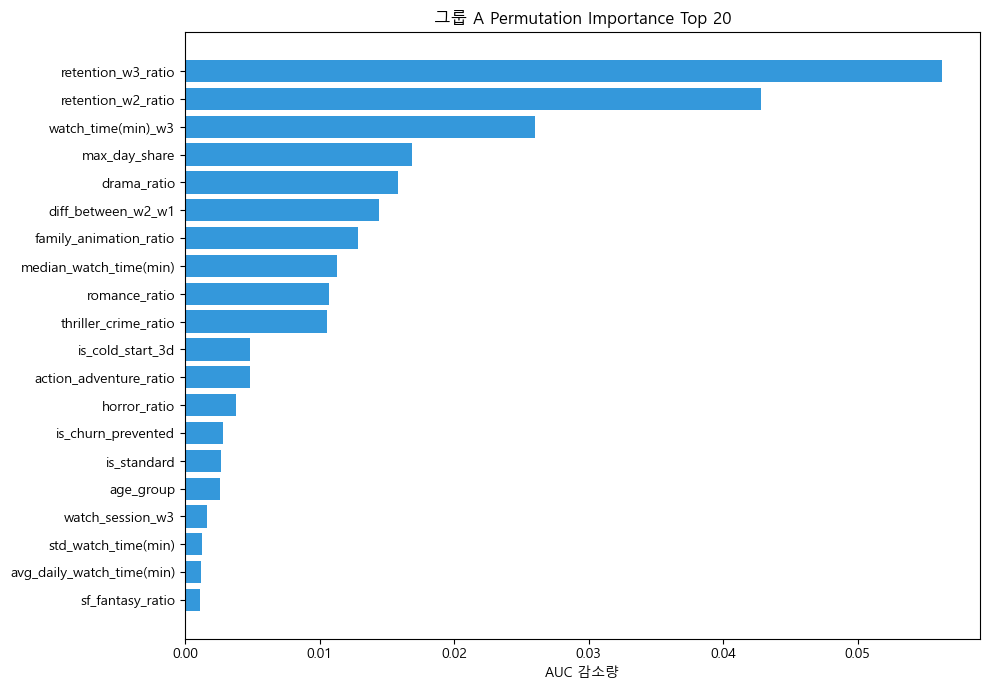

In [13]:
perm_A = permutation_importance(
    model_A, X_teA, y_teA, n_repeats=10, random_state=SEED, scoring='roc_auc', n_jobs=-1
)
perm_dfA = pd.DataFrame({'변수': FEAT_REF, 'AUC감소': perm_A.importances_mean}).sort_values('AUC감소', ascending=False).reset_index(drop=True)
perm_dfA.index += 1
print('=== 그룹 A Permutation Importance ===')
print(perm_dfA.head(20).to_string())

fig, ax = plt.subplots(figsize=(10, 7))
top = perm_dfA.head(20)
ax.barh(top['변수'][::-1], top['AUC감소'][::-1], color='#3498db')
ax.set_title('그룹 A Permutation Importance Top 20')
ax.set_xlabel('AUC 감소량')
plt.tight_layout(); plt.show()

### A-3. Surrogate Tree

=== 그룹 A Surrogate Tree 규칙 ===
|--- watch_time(min)_w3 <= 2.50
|   |--- diff_between_w2_w1 <= 22.50
|   |   |--- max_day_share <= 0.46
|   |   |   |--- reg_hour_evening <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- reg_hour_evening >  0.50
|   |   |   |   |--- class: 0
|   |   |--- max_day_share >  0.46
|   |   |   |--- avg_gap_between_watch_days <= 2.08
|   |   |   |   |--- class: 0
|   |   |   |--- avg_gap_between_watch_days >  2.08
|   |   |   |   |--- class: 0
|   |--- diff_between_w2_w1 >  22.50
|   |   |--- thriller_crime_ratio <= 0.32
|   |   |   |--- action_adventure_ratio <= 0.40
|   |   |   |   |--- class: 1
|   |   |   |--- action_adventure_ratio >  0.40
|   |   |   |   |--- class: 1
|   |   |--- thriller_crime_ratio >  0.32
|   |   |   |--- diff_between_w2_w1 <= 127.50
|   |   |   |   |--- class: 0
|   |   |   |--- diff_between_w2_w1 >  127.50
|   |   |   |   |--- class: 1
|--- watch_time(min)_w3 >  2.50
|   |--- watch_time(min)_w3 <= 84.50
|   |   |--- action_adve

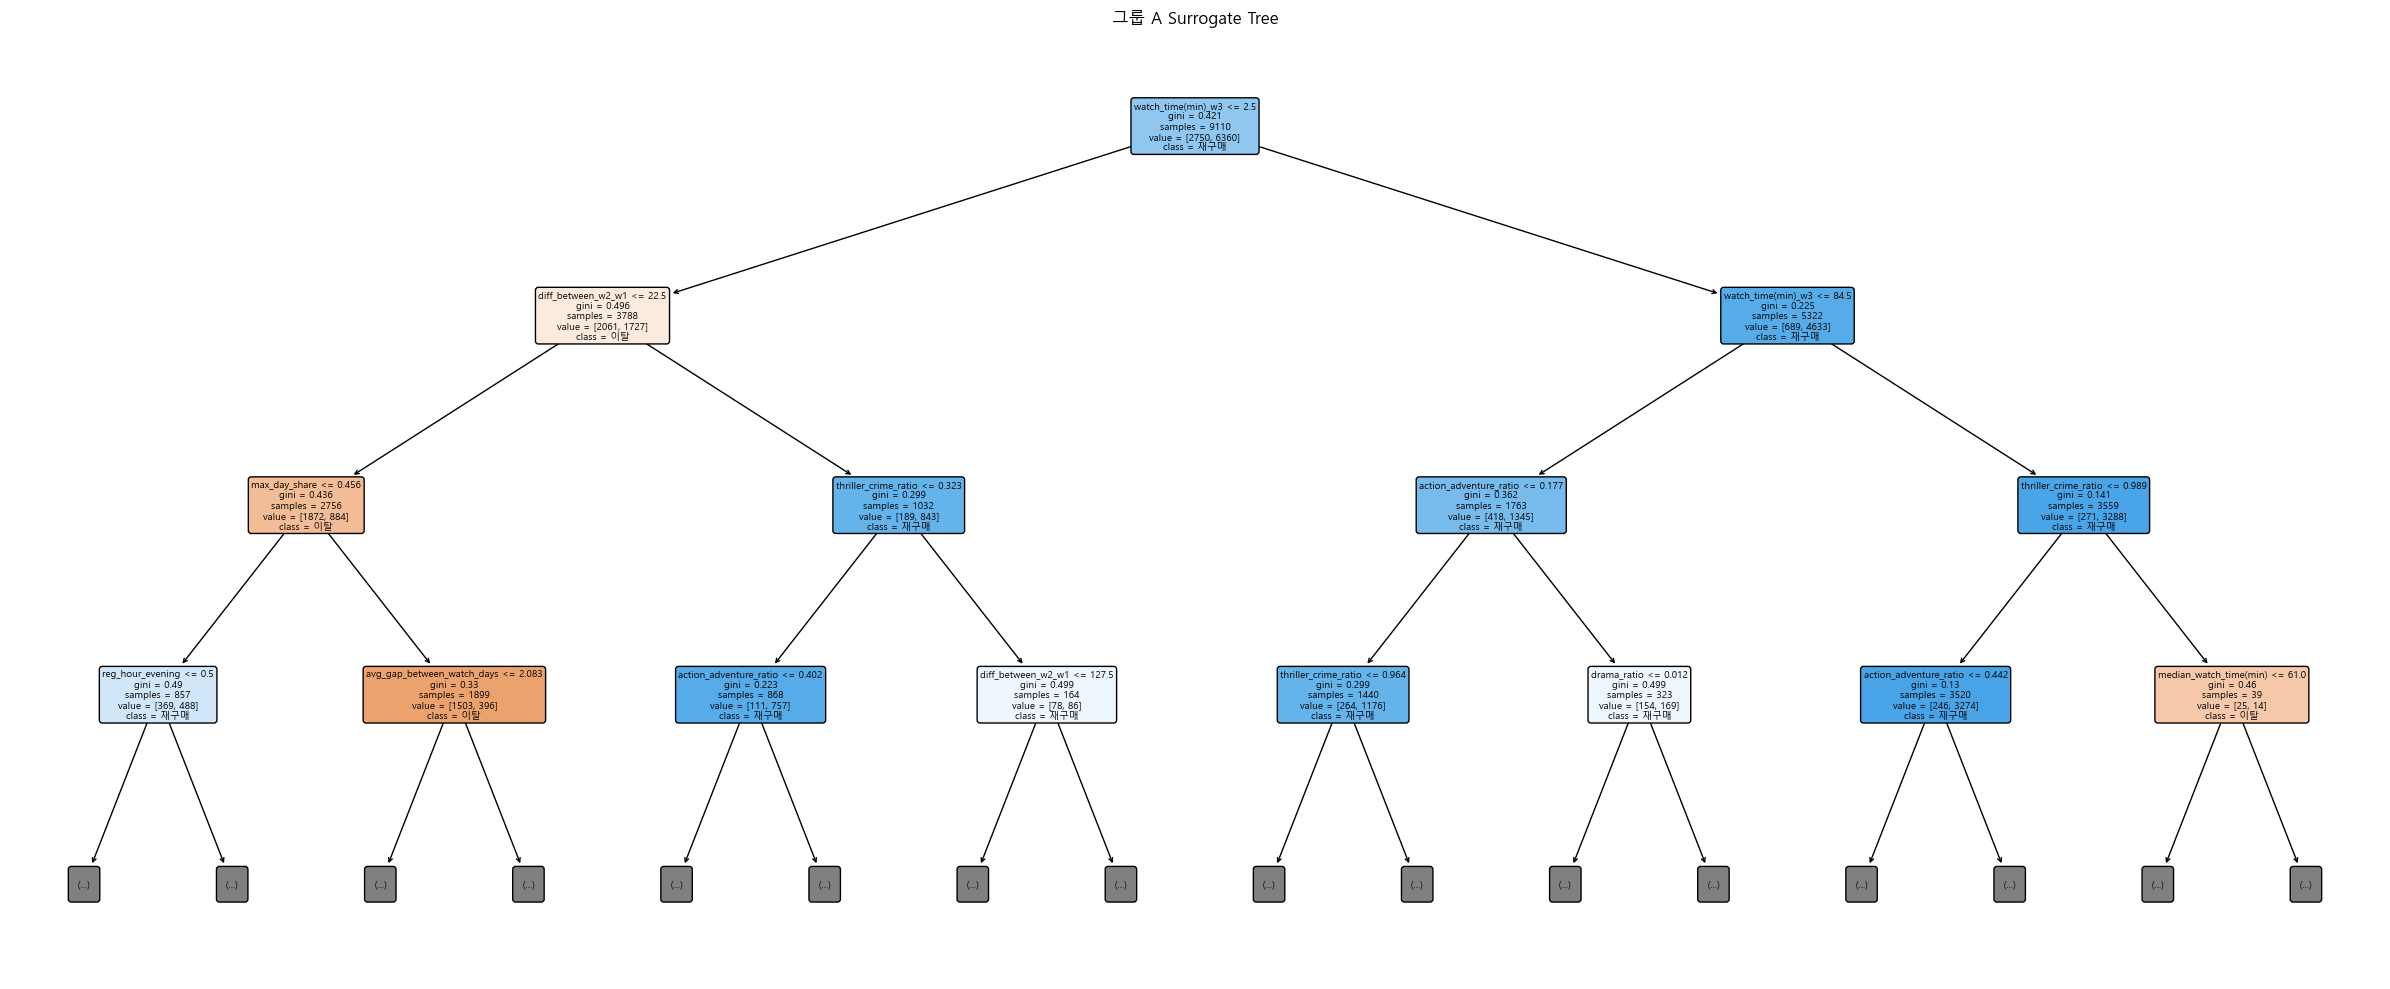

In [14]:
y_pred_trA = (model_A.predict_proba(X_trA)[:,1] > 0.5).astype(int)
surr_A = DecisionTreeClassifier(max_depth=4, random_state=SEED)
surr_A.fit(X_trA, y_pred_trA)
print('=== 그룹 A Surrogate Tree 규칙 ===')
print(export_text(surr_A, feature_names=list(FEAT_REF), max_depth=4))
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(surr_A, feature_names=list(FEAT_REF), class_names=['이탈','재구매'],
          filled=True, rounded=True, ax=ax, max_depth=3, fontsize=7)
plt.title('그룹 A Surrogate Tree')
plt.tight_layout(); plt.show()

### A-4. Counterfactual

선택 고객 재구매 확률: 1.0%

=== 그룹 A Counterfactual ===
                 변경 변수  원래 값  변경 값(Q75)  원래 확률  변경 후 확률  확률 변화
    watch_time(min)_w3   2.0     137.00   0.01    0.051  0.040
           drama_ratio   0.0       0.28   0.01    0.034  0.024
         romance_ratio   0.0       0.03   0.01    0.028  0.018
action_adventure_ratio   0.5       0.07   0.01    0.021  0.010
         max_day_share   1.0       0.91   0.01    0.018  0.007
    diff_between_w2_w1   0.0      65.00   0.01    0.017  0.006
    retention_w3_ratio   3.0       3.94   0.01    0.014  0.003
    retention_w2_ratio   1.0       3.62   0.01    0.013  0.003
  thriller_crime_ratio   0.0       0.16   0.01    0.012  0.001
family_animation_ratio   0.0       0.00   0.01    0.010  0.000


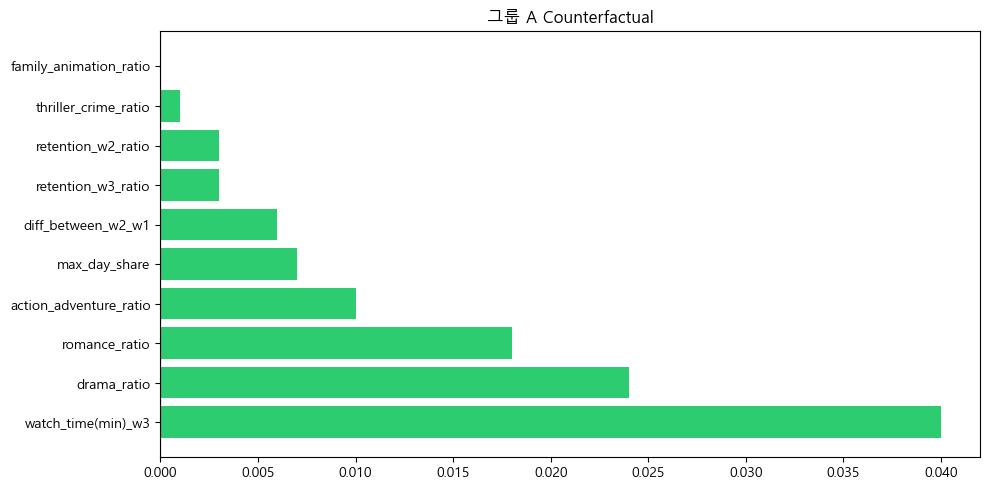

In [15]:
ypr_teA  = model_A.predict_proba(X_teA)[:,1]
c_mask_A = (ypr_teA < 0.4) & (y_teA.values == 0)
c_idx_A  = np.where(c_mask_A)[0]
top_A    = c_idx_A[np.argsort(ypr_teA[c_idx_A])[0]]
user_A   = X_teA.iloc[top_A]
base_A   = model_A.predict_proba(user_A.values.reshape(1,-1))[0,1]
print(f'선택 고객 재구매 확률: {base_A:.1%}')

rows_A = []
for feat in shap_dfA['변수'].head(10).tolist():
    cf = user_A.copy(); cf[feat] = X_teA[feat].quantile(0.75)
    cp = model_A.predict_proba(cf.values.reshape(1,-1))[0,1]
    rows_A.append({'변경 변수': feat, '원래 값': round(user_A[feat],2),
                   '변경 값(Q75)': round(X_teA[feat].quantile(0.75),2),
                   '원래 확률': round(base_A,3), '변경 후 확률': round(cp,3),
                   '확률 변화': round(cp-base_A,3)})
cf_A = pd.DataFrame(rows_A).sort_values('확률 변화', ascending=False)
print('\n=== 그룹 A Counterfactual ===')
print(cf_A.to_string(index=False))
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(cf_A['변경 변수'], cf_A['확률 변화'],
        color=['#2ecc71' if v>0 else '#e74c3c' for v in cf_A['확률 변화']])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('그룹 A Counterfactual')
plt.tight_layout(); plt.show()

---
## 4. 그룹 B: is_promotion = 1 (프로모션 가입)

### B-1. 모델 학습 & SHAP

[그룹 B] AUC=0.8672  F1=0.8259
Precision: 0.8817  Recall: 0.7767


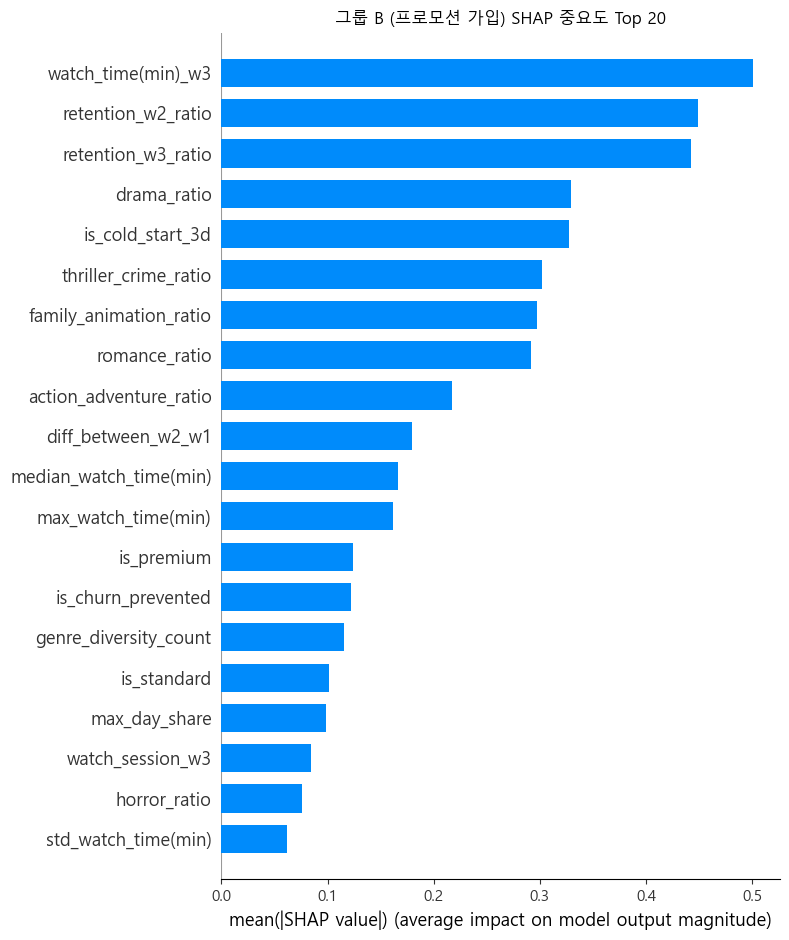

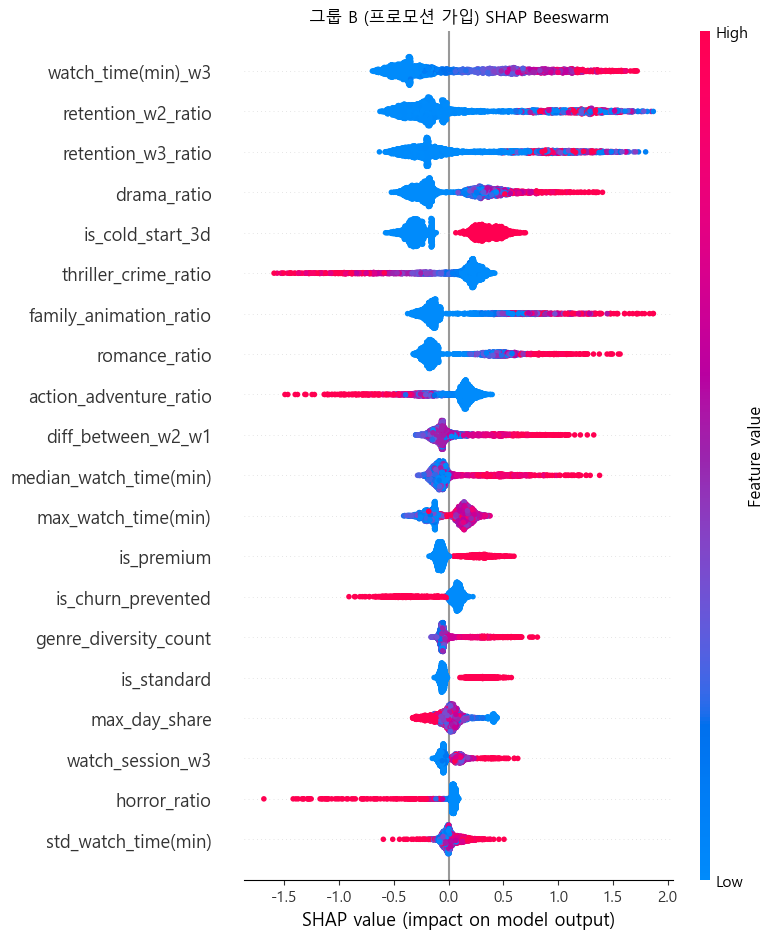

=== 그룹 B SHAP 중요도 (상위 20) ===
                        변수      SHAP
1       watch_time(min)_w3  0.501097
2       retention_w2_ratio  0.449338
3       retention_w3_ratio  0.442251
4              drama_ratio  0.328965
5         is_cold_start_3d  0.327694
6     thriller_crime_ratio  0.301610
7   family_animation_ratio  0.297049
8            romance_ratio  0.291419
9   action_adventure_ratio  0.217027
10      diff_between_w2_w1  0.179138
11  median_watch_time(min)  0.166410
12     max_watch_time(min)  0.161411
13              is_premium  0.124306
14      is_churn_prevented  0.122114
15   genre_diversity_count  0.115791
16             is_standard  0.100850
17           max_day_share  0.098938
18        watch_session_w3  0.084792
19            horror_ratio  0.076225
20     std_watch_time(min)  0.061653


In [16]:
X_trB, X_teB, y_trB, y_teB = train_test_split(
    XB, yB, test_size=0.2, stratify=yB, random_state=SEED
)
spwB = (y_trB==0).sum() / (y_trB==1).sum()
model_B = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    scale_pos_weight=spwB, subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', early_stopping_rounds=50,
    random_state=SEED, n_jobs=-1, verbosity=0
)
model_B.fit(X_trB, y_trB, eval_set=[(X_teB, y_teB)], verbose=False)

ypB  = model_B.predict(X_teB)
yprB = model_B.predict_proba(X_teB)[:,1]
print(f'[그룹 B] AUC={roc_auc_score(y_teB, yprB):.4f}  F1={f1_score(y_teB, ypB):.4f}')
print(f'Precision: {precision_score(y_teB, ypB):.4f}  Recall: {recall_score(y_teB, ypB):.4f}')

exp_B   = shap.TreeExplainer(model_B)
shap_B  = exp_B.shap_values(X_teB)
shap_dfB = pd.DataFrame({'변수': FEAT_REF, 'SHAP': np.abs(shap_B).mean(axis=0)}).sort_values('SHAP', ascending=False).reset_index(drop=True)
shap_dfB.index += 1

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_B, X_teB, plot_type='bar', show=False, max_display=20)
plt.title('그룹 B (프로모션 가입) SHAP 중요도 Top 20')
plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_B, X_teB, show=False, max_display=20)
plt.title('그룹 B (프로모션 가입) SHAP Beeswarm')
plt.tight_layout(); plt.show()

print('=== 그룹 B SHAP 중요도 (상위 20) ===')
print(shap_dfB.head(20).to_string())

### B-2. Permutation Importance

=== 그룹 B Permutation Importance ===
                        변수     AUC감소
1       retention_w2_ratio  0.050671
2       retention_w3_ratio  0.043901
3       watch_time(min)_w3  0.032123
4              drama_ratio  0.018016
5     thriller_crime_ratio  0.017644
6            romance_ratio  0.016411
7   family_animation_ratio  0.016023
8         is_cold_start_3d  0.013429
9   action_adventure_ratio  0.010577
10  median_watch_time(min)  0.010447
11           max_day_share  0.006497
12      diff_between_w2_w1  0.006072
13     max_watch_time(min)  0.004509
14              is_premium  0.003801
15      is_churn_prevented  0.003672
16            horror_ratio  0.003328
17   genre_diversity_count  0.002562
18    watch_ratio_under_5m  0.001477
19    movie_per_active_day  0.001319
20                 recency  0.001268


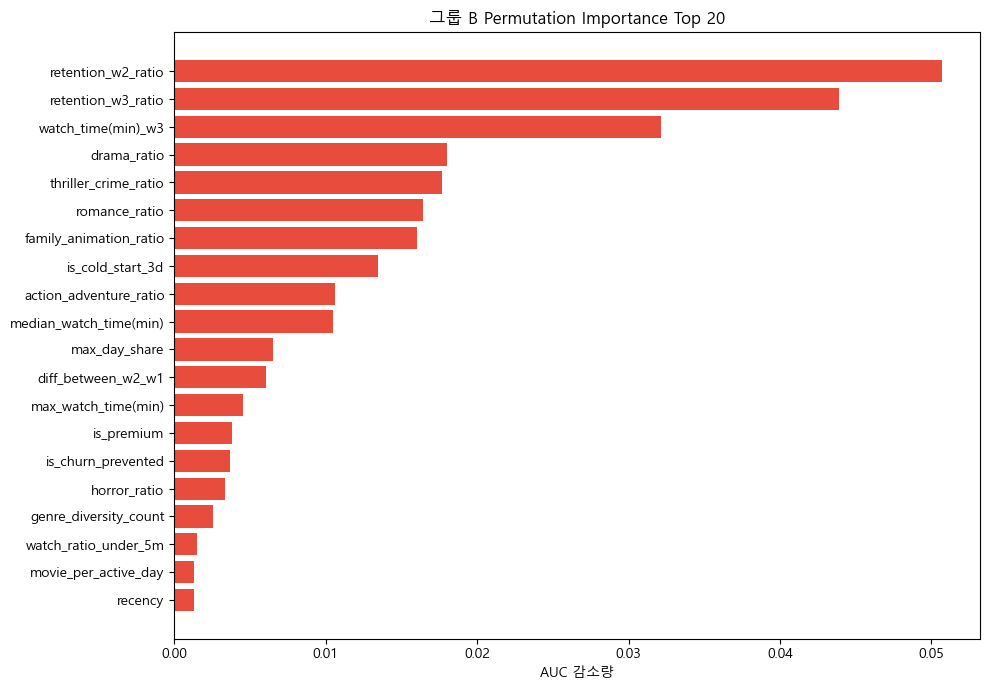

In [17]:
perm_B = permutation_importance(
    model_B, X_teB, y_teB, n_repeats=10, random_state=SEED, scoring='roc_auc', n_jobs=-1
)
perm_dfB = pd.DataFrame({'변수': FEAT_REF, 'AUC감소': perm_B.importances_mean}).sort_values('AUC감소', ascending=False).reset_index(drop=True)
perm_dfB.index += 1
print('=== 그룹 B Permutation Importance ===')
print(perm_dfB.head(20).to_string())

fig, ax = plt.subplots(figsize=(10, 7))
top = perm_dfB.head(20)
ax.barh(top['변수'][::-1], top['AUC감소'][::-1], color='#e74c3c')
ax.set_title('그룹 B Permutation Importance Top 20')
ax.set_xlabel('AUC 감소량')
plt.tight_layout(); plt.show()

### B-3. Surrogate Tree

=== 그룹 B Surrogate Tree 규칙 ===
|--- watch_time(min)_w3 <= 7.50
|   |--- diff_between_w2_w1 <= 11.50
|   |   |--- max_day_share <= 0.97
|   |   |   |--- is_premium <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- is_premium >  0.50
|   |   |   |   |--- class: 0
|   |   |--- max_day_share >  0.97
|   |   |   |--- median_watch_time(min) <= 123.00
|   |   |   |   |--- class: 0
|   |   |   |--- median_watch_time(min) >  123.00
|   |   |   |   |--- class: 1
|   |--- diff_between_w2_w1 >  11.50
|   |   |--- thriller_crime_ratio <= 0.52
|   |   |   |--- action_adventure_ratio <= 0.49
|   |   |   |   |--- class: 1
|   |   |   |--- action_adventure_ratio >  0.49
|   |   |   |   |--- class: 0
|   |   |--- thriller_crime_ratio >  0.52
|   |   |   |--- diff_between_w2_w1 <= 100.50
|   |   |   |   |--- class: 0
|   |   |   |--- diff_between_w2_w1 >  100.50
|   |   |   |   |--- class: 1
|--- watch_time(min)_w3 >  7.50
|   |--- watch_time(min)_w3 <= 132.50
|   |   |--- drama_ratio <= 0.00
|   | 

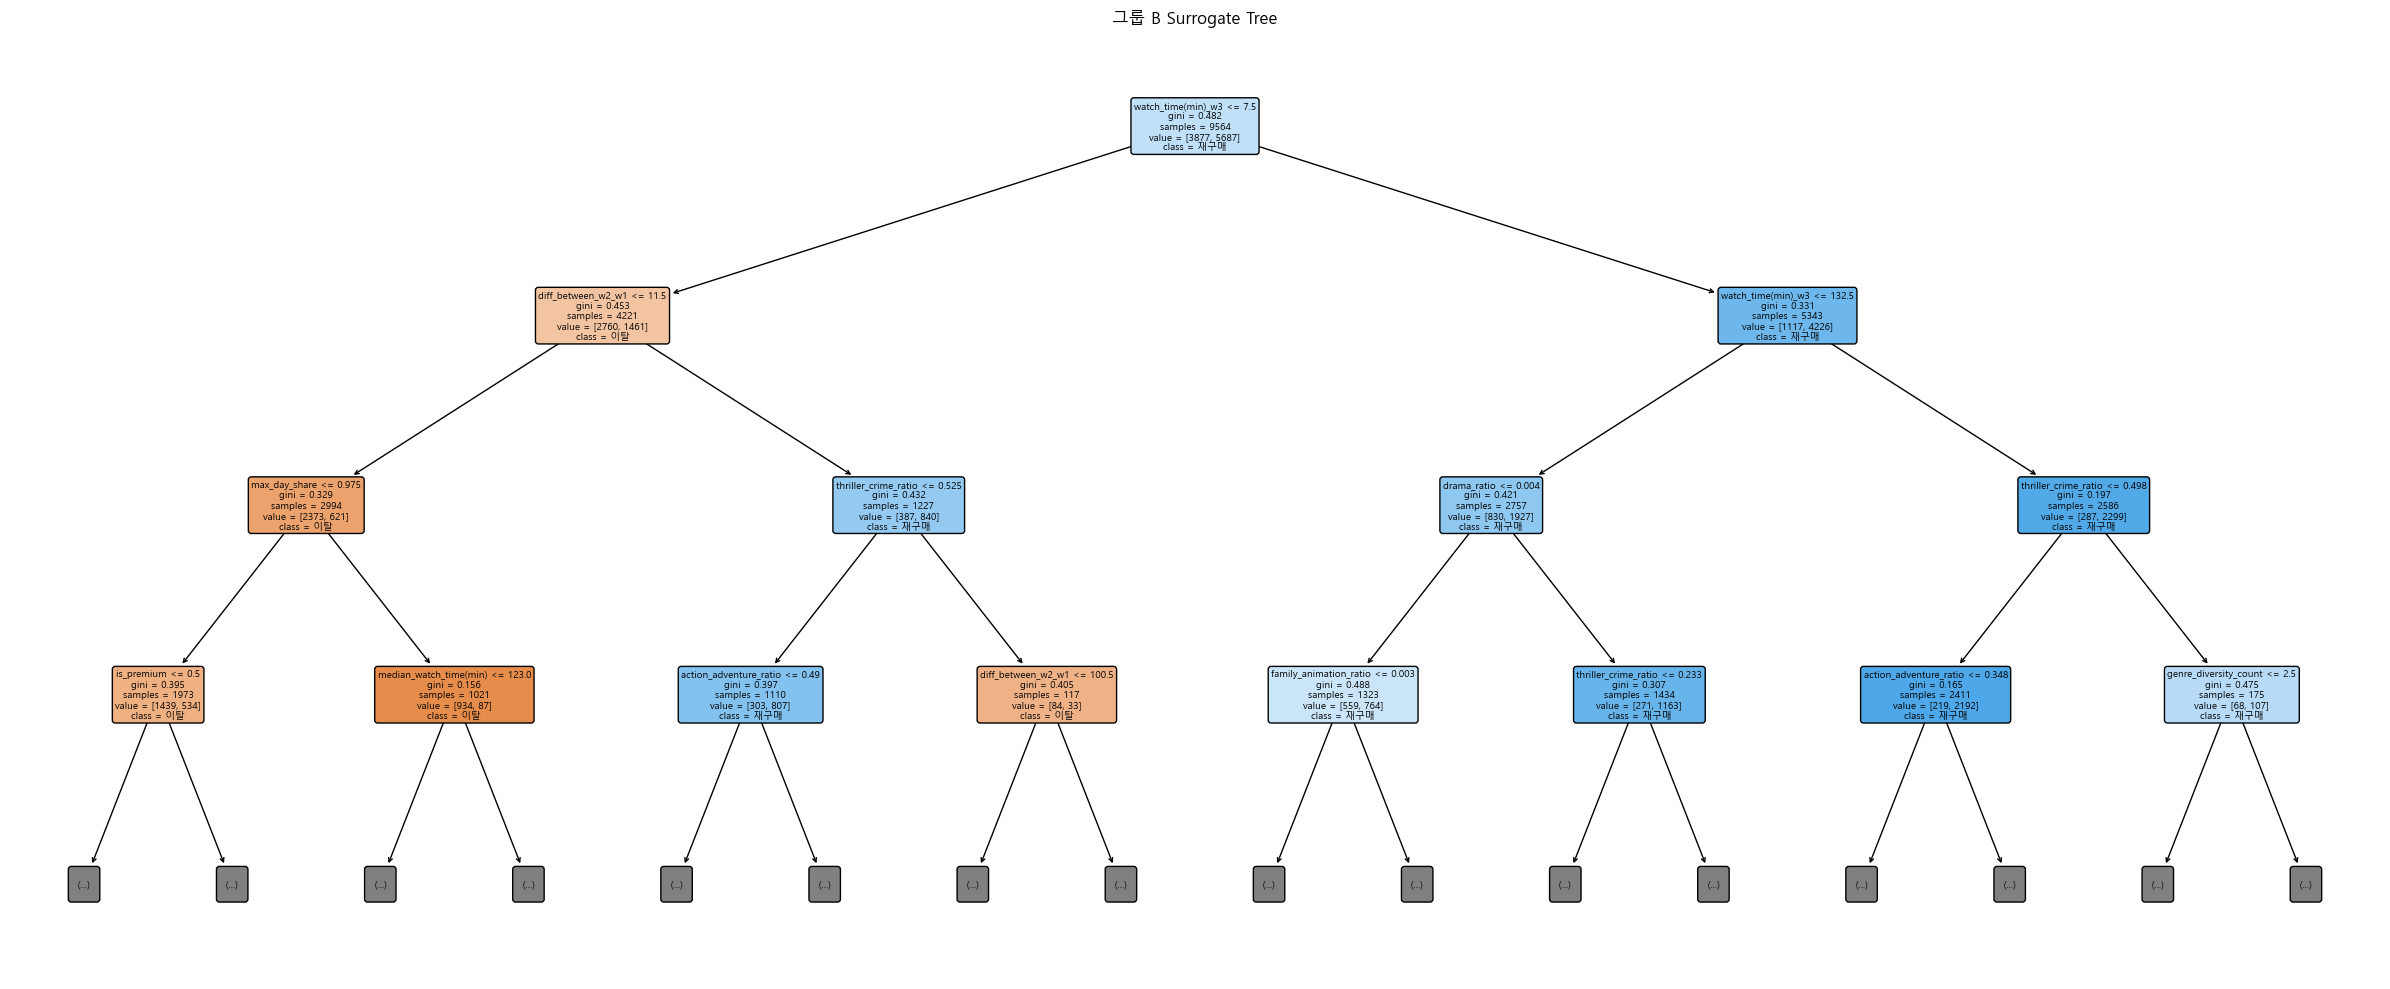

In [18]:
y_pred_trB = (model_B.predict_proba(X_trB)[:,1] > 0.5).astype(int)
surr_B = DecisionTreeClassifier(max_depth=4, random_state=SEED)
surr_B.fit(X_trB, y_pred_trB)
print('=== 그룹 B Surrogate Tree 규칙 ===')
print(export_text(surr_B, feature_names=list(FEAT_REF), max_depth=4))
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(surr_B, feature_names=list(FEAT_REF), class_names=['이탈','재구매'],
          filled=True, rounded=True, ax=ax, max_depth=3, fontsize=7)
plt.title('그룹 B Surrogate Tree')
plt.tight_layout(); plt.show()

### B-4. Counterfactual

선택 고객 재구매 확률: 2.1%

=== 그룹 B Counterfactual ===
                 변경 변수   원래 값  변경 값(Q75)  원래 확률  변경 후 확률  확률 변화
    watch_time(min)_w3   0.00     143.00  0.021    0.070  0.049
         romance_ratio   0.00       0.04  0.021    0.036  0.015
    retention_w3_ratio   1.00       4.72  0.021    0.032  0.011
      is_cold_start_3d   0.00       1.00  0.021    0.030  0.009
           drama_ratio   0.00       0.25  0.021    0.028  0.007
    retention_w2_ratio   0.01       3.04  0.021    0.026  0.005
action_adventure_ratio   0.20       0.08  0.021    0.023  0.002
    diff_between_w2_w1 -75.00      53.00  0.021    0.023  0.002
family_animation_ratio   0.00       0.00  0.021    0.021  0.000
  thriller_crime_ratio   0.00       0.16  0.021    0.016 -0.005


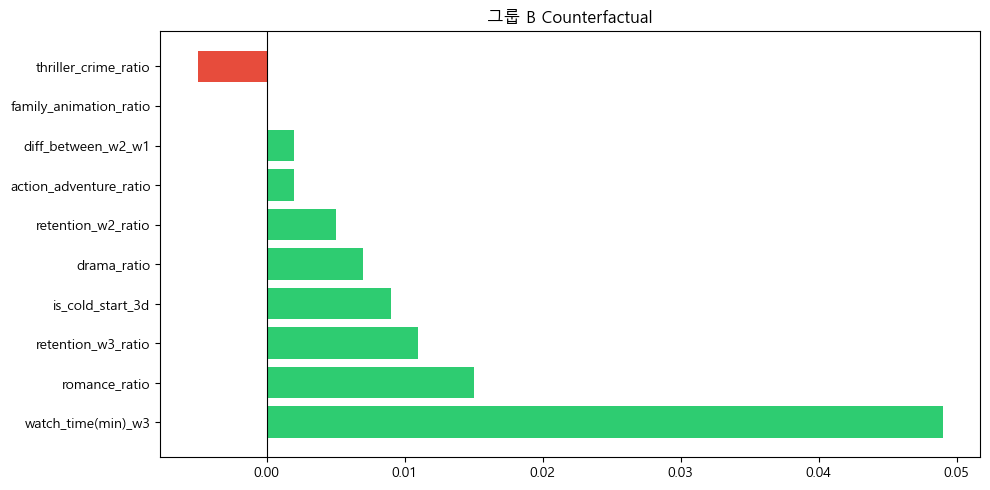

In [19]:
ypr_teB  = model_B.predict_proba(X_teB)[:,1]
c_mask_B = (ypr_teB < 0.4) & (y_teB.values == 0)
c_idx_B  = np.where(c_mask_B)[0]
top_B    = c_idx_B[np.argsort(ypr_teB[c_idx_B])[0]]
user_B   = X_teB.iloc[top_B]
base_B   = model_B.predict_proba(user_B.values.reshape(1,-1))[0,1]
print(f'선택 고객 재구매 확률: {base_B:.1%}')

rows_B = []
for feat in shap_dfB['변수'].head(10).tolist():
    cf = user_B.copy(); cf[feat] = X_teB[feat].quantile(0.75)
    cp = model_B.predict_proba(cf.values.reshape(1,-1))[0,1]
    rows_B.append({'변경 변수': feat, '원래 값': round(user_B[feat],2),
                   '변경 값(Q75)': round(X_teB[feat].quantile(0.75),2),
                   '원래 확률': round(base_B,3), '변경 후 확률': round(cp,3),
                   '확률 변화': round(cp-base_B,3)})
cf_B = pd.DataFrame(rows_B).sort_values('확률 변화', ascending=False)
print('\n=== 그룹 B Counterfactual ===')
print(cf_B.to_string(index=False))
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(cf_B['변경 변수'], cf_B['확률 변화'],
        color=['#2ecc71' if v>0 else '#e74c3c' for v in cf_B['확률 변화']])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('그룹 B Counterfactual')
plt.tight_layout(); plt.show()

---
## 5. 그룹 A vs 그룹 B SHAP 중요도 비교

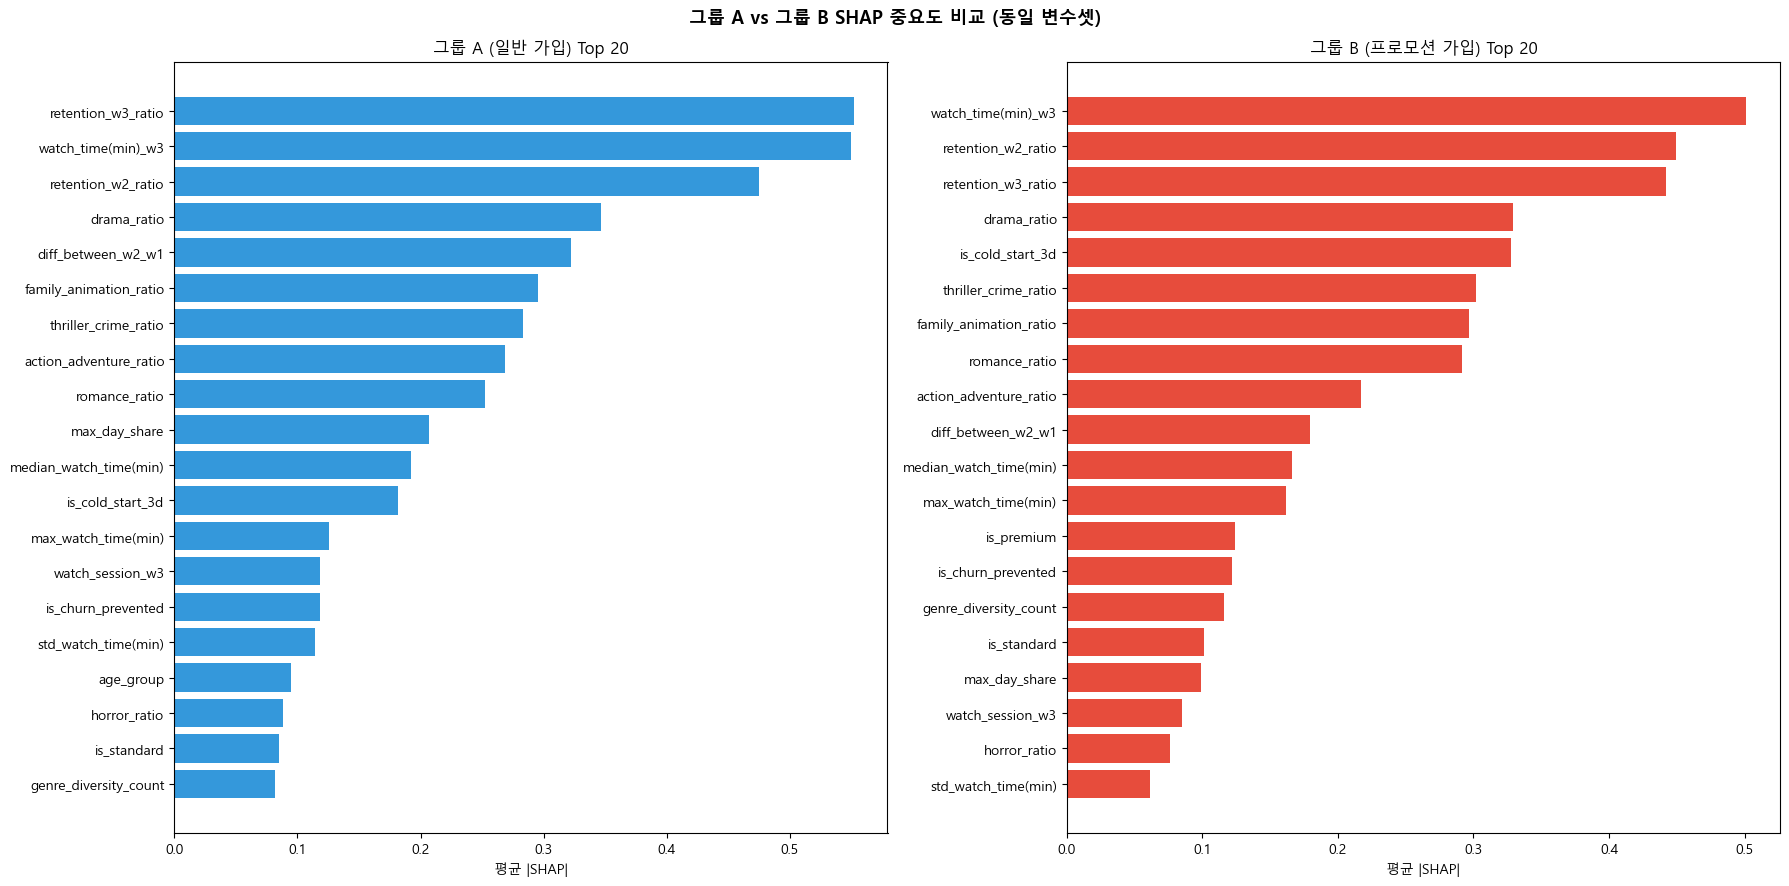

=== 그룹 간 SHAP 차이 (절대값 큰 순서) ===
양수: 프로모션 그룹에서 더 중요  /  음수: 일반 그룹에서 더 중요

                            변수   그룹A(일반)  그룹B(프로모션)   차이(B-A)
1             is_cold_start_3d  0.181831   0.327694  0.145864
2           diff_between_w2_w1  0.322541   0.179138 -0.143403
3           retention_w3_ratio  0.551742   0.442251 -0.109492
4                max_day_share  0.206930   0.098938 -0.107992
5                   is_premium  0.022187   0.124306  0.102119
6             reg_hour_evening  0.069262   0.011009 -0.058253
7          std_watch_time(min)  0.114047   0.061653 -0.052394
8       action_adventure_ratio  0.268638   0.217027 -0.051611
9   avg_gap_between_watch_days  0.079405   0.030328 -0.049078
10          watch_time(min)_w3  0.549469   0.501097 -0.048372
11              payment_is_ios  0.043770   0.000000 -0.043770
12                   age_group  0.094876   0.053028 -0.041847
13                comedy_ratio  0.067439   0.027617 -0.039822
14                   is_female  0.049495   0.009742 -0.0397

In [20]:
# 나란히 바 차트
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
for ax, shap_vals, title, color in zip(
    axes,
    [shap_A, shap_B],
    ['그룹 A (일반 가입) Top 20', '그룹 B (프로모션 가입) Top 20'],
    ['#3498db', '#e74c3c']
):
    imp = pd.DataFrame({'변수': FEAT_REF, 'SHAP': np.abs(shap_vals).mean(axis=0)}).sort_values('SHAP').tail(20)
    ax.barh(imp['변수'], imp['SHAP'], color=color)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('평균 |SHAP|')
plt.suptitle('그룹 A vs 그룹 B SHAP 중요도 비교 (동일 변수셋)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# 수치 비교: 차이 큰 변수 순
comp = pd.DataFrame({
    '변수':        FEAT_REF,
    '그룹A(일반)':    np.abs(shap_A).mean(axis=0),
    '그룹B(프로모션)': np.abs(shap_B).mean(axis=0),
})
comp['차이(B-A)'] = comp['그룹B(프로모션)'] - comp['그룹A(일반)']
comp = comp.sort_values('차이(B-A)', key=abs, ascending=False).reset_index(drop=True)
comp.index += 1
print('=== 그룹 간 SHAP 차이 (절대값 큰 순서) ===')
print('양수: 프로모션 그룹에서 더 중요  /  음수: 일반 그룹에서 더 중요\n')
print(comp.head(20).to_string())